# M3 · Experiment 5 — The meta-questions

E1-E4 generated a lot of numbers. E5 stands back and asks two questions across all of them:

1. **Parameter fragility / overfitting** — when the same strategy idea produces returns from -10% to +68% depending on parameters, what does that *mean*? Can we quantify how much picking-in-hindsight is helping?
2. **Fee leakage** — at default fee/slippage assumptions, how much of the gross return are fees actually eating? Can this explain "why retail crypto quants mostly lose money"?

These are the questions that determine whether M3's findings generalize beyond this specific sample.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from hindcast.backtest.engine import BacktestEngine
from hindcast.backtest.execution import SimpleExecutionModel
from hindcast.backtest.portfolio import Portfolio
from hindcast.backtest.strategies.bollinger_meanrev import BollingerMeanReversion
from hindcast.backtest.strategies.buy_and_hold import BuyAndHold
from hindcast.backtest.strategies.ma_crossover import MACrossover
from hindcast.backtest.types import Bar
from hindcast.config import settings
from hindcast.data.storage import Storage

storage = Storage(settings.db_path)
START = pd.Timestamp('2024-01-01', tz='UTC')
END = pd.Timestamp('2026-01-01', tz='UTC')
INITIAL_CASH = 10_000.0
ALLOC = 0.99

_btc_df = storage.query_ohlcv('binance', 'BTC/USDT', '1d', start=START, end=END)
BTC_BARS = [Bar.from_series(row) for _, row in _btc_df.iterrows()]

def run(strategy, fee_pct=0.001, slip_pct=0.0005):
    engine = BacktestEngine(
        strategy,
        SimpleExecutionModel(fee_pct=fee_pct, slippage_pct=slip_pct),
        Portfolio(INITIAL_CASH),
    )
    return engine.run(BTC_BARS)

BH = run(BuyAndHold(ALLOC)).metrics.total_return
print(f'BTC buy_and_hold baseline: {BH:+.2%}')

BTC buy_and_hold baseline: +97.26%


## 1. Parameter fragility — quantifying the spread

Re-run E2 and E3 sweeps and compute concrete fragility metrics:
- **Range**: max - min
- **Spread coefficient**: range / |median| (how big is the variation relative to the typical result?)
- **Pick-blind probability**: P(random param > baseline) — if you knew nothing about which params to pick, how often would you have beaten doing nothing?

In [2]:
# E2 sweep
ma_results = []
for f in [5, 10, 20, 50]:
    for s in [20, 50, 100, 200]:
        if f >= s:
            continue
        r = run(MACrossover(f, s, ALLOC))
        ma_results.append({'family': 'MA', 'fast': f, 'slow': s,
                          'total_return': r.metrics.total_return,
                          'n_trades': r.metrics.n_trades})

# E3 sweep
bb_results = []
for w in [10, 20, 50]:
    for n in [1.5, 2.0, 2.5]:
        r = run(BollingerMeanReversion(w, n, ALLOC))
        bb_results.append({'family': 'Bollinger', 'window': w, 'n_std': n,
                          'total_return': r.metrics.total_return,
                          'n_trades': r.metrics.n_trades})

ma_df = pd.DataFrame(ma_results)
bb_df = pd.DataFrame(bb_results)

def fragility(df, name):
    rets = df['total_return']
    return {
        'family': name,
        'n_variants': len(df),
        'best': f"{rets.max():+.2%}",
        'median': f"{rets.median():+.2%}",
        'worst': f"{rets.min():+.2%}",
        'range_pp': f"{(rets.max() - rets.min()) * 100:.1f}",
        'std_pp': f"{rets.std() * 100:.1f}",
        'spread_coeff': f"{(rets.max() - rets.min()) / abs(rets.median()):.2f}",
        'p_beat_bh': f"{(rets > BH).mean():.0%}",
    }

frag = pd.DataFrame([
    fragility(ma_df, 'MA crossover'),
    fragility(bb_df, 'Bollinger mean-revert'),
]).set_index('family')
frag

,n_variants,best,median,worst,range_pp,std_pp,spread_coeff,p_beat_bh
family,,,,,,,,
MA crossover,13,+67.54%,+26.83%,-9.80%,77.3,23.1,2.88,0%
Bollinger mean-revert,9,+53.17%,+24.25%,+1.74%,51.4,18.4,2.12,0%


Visualize the distributions side by side. The key story: how *wide* is each strategy family's range relative to where the baseline is.

/var/folders/q8/3q72g1t155s1w33frqgflmqw0000gn/T/ipykernel_47584/3394221950.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, widths=0.5, patch_artist=True,


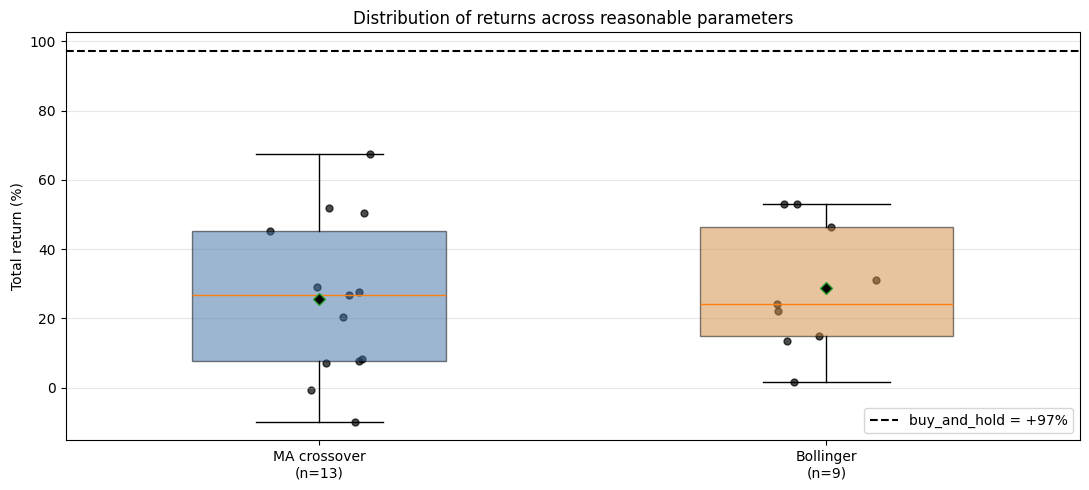

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
data = [ma_df['total_return'].values * 100, bb_df['total_return'].values * 100]
labels = [f'MA crossover\n(n={len(ma_df)})', f'Bollinger\n(n={len(bb_df)})']
bp = ax.boxplot(data, labels=labels, widths=0.5, patch_artist=True,
                showmeans=True, meanprops=dict(marker='D', markerfacecolor='black'))
for patch, color in zip(bp['boxes'], ['#3a6ea5', '#d18b3f']):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
# Scatter individual points
for i, d in enumerate(data, start=1):
    jitter = np.random.uniform(-0.1, 0.1, len(d))
    ax.scatter(np.full(len(d), i) + jitter, d, alpha=0.7, color='black', s=25)
ax.axhline(BH * 100, color='black', linestyle='--', linewidth=1.5, label=f'buy_and_hold = {BH:+.0%}')
ax.set_ylabel('Total return (%)')
ax.set_title('Distribution of returns across reasonable parameters')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 2. Fee leakage — what fees actually cost

Re-run the *best* MA and *best* Bollinger from E2/E3 across four fee/slippage tiers:
- **Zero**: 0% fee, 0% slip (the headline-shopping number)
- **Maker** : 0.05% fee, 0.025% slip (Binance maker tier, light slippage)
- **Default**: 0.10% fee, 0.05% slip (Binance taker tier 0)
- **Pessimistic**: 0.20% fee, 0.10% slip (small account, no rebates, real spreads)

And tabulate.

In [4]:
FEE_TIERS = [
    ('zero',        0.0,    0.0),
    ('maker',       0.0005, 0.00025),
    ('default',     0.001,  0.0005),
    ('pessimistic', 0.002,  0.001),
]

def fee_sweep(name, factory):
    rows = []
    for tier, fee, slip in FEE_TIERS:
        r = run(factory(), fee_pct=fee, slip_pct=slip)
        rows.append({
            'strategy': name,
            'tier': tier,
            'fee_%': f'{fee*100:.2f}',
            'slip_%': f'{slip*100:.3f}',
            'total_return': r.metrics.total_return,
            'n_trades': r.metrics.n_trades,
        })
    return rows

ma_best = lambda: MACrossover(10, 20, ALLOC)        # E2 best on BTC
bb_best = lambda: BollingerMeanReversion(20, 2.0, ALLOC)  # E3 best on BTC
bh = lambda: BuyAndHold(ALLOC)

all_rows = fee_sweep('buy_and_hold', bh) + fee_sweep('MA(10, 20)', ma_best) + fee_sweep('BB(20, 2.0)', bb_best)
fee_df = pd.DataFrame(all_rows)

# Pivot for readability
pivot = fee_df.pivot(index='strategy', columns='tier', values='total_return')
pivot = pivot[['zero', 'maker', 'default', 'pessimistic']]  # column order
for col in pivot.columns:
    pivot[col] = pivot[col].map('{:+.2%}'.format)
print('Total return by fee tier:')
print(pivot.to_string())

# Compute the absolute and relative fee drag
drag = fee_df.pivot(index='strategy', columns='tier', values='total_return')
drag['default_vs_zero_pp'] = (drag['default'] - drag['zero']) * 100
drag['pessimistic_vs_zero_pp'] = (drag['pessimistic'] - drag['zero']) * 100
drag['n_trades_default'] = fee_df[fee_df['tier'] == 'default'].set_index('strategy')['n_trades']
print('\nFee drag (in percentage points of total return):')
print(drag[['default_vs_zero_pp', 'pessimistic_vs_zero_pp', 'n_trades_default']].round(2).to_string())

Total return by fee tier:
tier             zero    maker  default pessimistic
strategy                                           
BB(20, 2.0)   +57.46%  +55.30%  +53.17%     +48.98%
MA(10, 20)    +76.65%  +72.04%  +67.54%     +58.87%
buy_and_hold  +97.41%  +97.33%  +97.26%     +97.11%

Fee drag (in percentage points of total return):
tier          default_vs_zero_pp  pessimistic_vs_zero_pp  n_trades_default
strategy                                                                  
BB(20, 2.0)                -4.29                   -8.48                 9
MA(10, 20)                 -9.11                  -17.78                18
buy_and_hold               -0.15                   -0.30                 0


Visualize how the fee drag compounds with trade count.

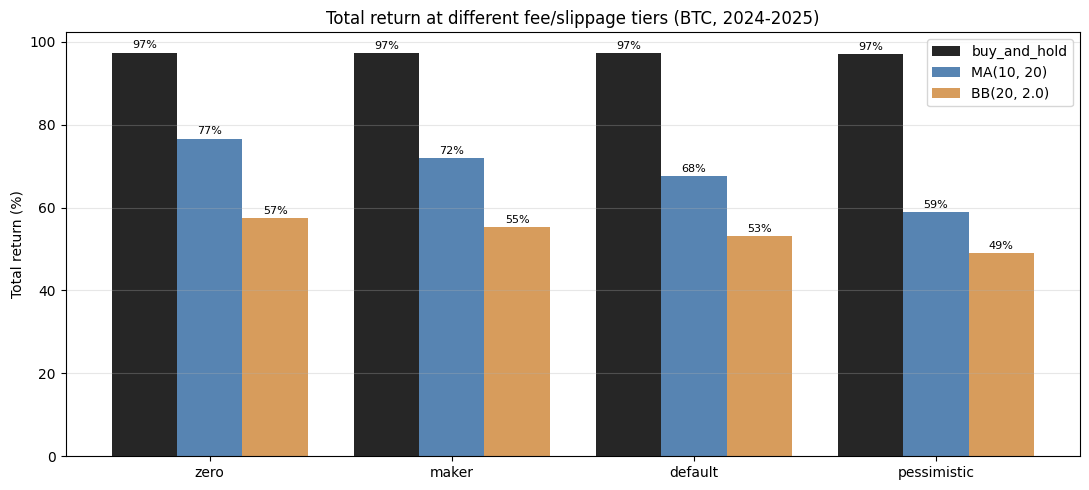

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
tiers = ['zero', 'maker', 'default', 'pessimistic']
x = np.arange(len(tiers))
w = 0.27

for i, (label, color) in enumerate([('buy_and_hold', '#000000'),
                                     ('MA(10, 20)', '#3a6ea5'),
                                     ('BB(20, 2.0)', '#d18b3f')]):
    vals = [fee_df[(fee_df['strategy'] == label) & (fee_df['tier'] == t)]['total_return'].iloc[0] * 100
            for t in tiers]
    ax.bar(x + (i - 1) * w, vals, width=w, label=label, color=color, alpha=0.85)
    for xi, v in zip(x + (i - 1) * w, vals):
        ax.text(xi, v + 1, f'{v:.0f}%', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(tiers)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_ylabel('Total return (%)')
ax.set_title('Total return at different fee/slippage tiers (BTC, 2024-2025)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 3. The master comparison table

Stitch all four experiments into a single scoreboard.

In [6]:
rows = [
    {
        'family': 'buy_and_hold (E1)',
        'variants': 1,
        'best_total_return': '+97.26%',
        'median_total_return': '+97.26%',
        'worst_total_return': '+97.26%',
        'beat_bh_BTC': 'baseline',
        'avg_n_trades': 1,
        'character': 'directional, fully exposed',
    },
    {
        'family': 'MA crossover (E2)',
        'variants': len(ma_df),
        'best_total_return': f"{ma_df['total_return'].max():+.2%}",
        'median_total_return': f"{ma_df['total_return'].median():+.2%}",
        'worst_total_return': f"{ma_df['total_return'].min():+.2%}",
        'beat_bh_BTC': f"{(ma_df['total_return'] > BH).sum()}/{len(ma_df)}",
        'avg_n_trades': int(ma_df['n_trades'].mean()),
        'character': 'trend-following, on/off',
    },
    {
        'family': 'Bollinger MR (E3)',
        'variants': len(bb_df),
        'best_total_return': f"{bb_df['total_return'].max():+.2%}",
        'median_total_return': f"{bb_df['total_return'].median():+.2%}",
        'worst_total_return': f"{bb_df['total_return'].min():+.2%}",
        'beat_bh_BTC': f"{(bb_df['total_return'] > BH).sum()}/{len(bb_df)}",
        'avg_n_trades': int(bb_df['n_trades'].mean()),
        'character': 'mean-reversion, conservative',
    },
    {
        'family': 'Funding carry (E4)',
        'variants': 'n/a',
        'best_total_return': '+8.40% (2y, 1x)',
        'median_total_return': 'n/a',
        'worst_total_return': 'n/a',
        'beat_bh_BTC': 'different category',
        'avg_n_trades': 'continuous',
        'character': 'market-neutral yield',
    },
]
master = pd.DataFrame(rows).set_index('family')
master

,variants,best_total_return,median_total_return,worst_total_return,beat_bh_BTC,avg_n_trades,character
family,,,,,,,
buy_and_hold (E1),1,+97.26%,+97.26%,+97.26%,baseline,1,"directional, fully exposed"
MA crossover (E2),13,+67.54%,+26.83%,-9.80%,0/13,8,"trend-following, on/off"
Bollinger MR (E3),9,+53.17%,+24.25%,+1.74%,0/9,7,"mean-reversion, conservative"
Funding carry (E4),n/a,"+8.40% (2y, 1x)",n/a,n/a,different category,continuous,market-neutral yield


## Takeaways

**1. Parameter fragility is real and measurable.** MA's 13 variants span 77 percentage points; Bollinger's 9 span 51. Pick-blind probability of beating buy-and-hold across both = **0%** (BTC) and a few percent (ETH for MA). When you read "my strategy returned X%", the missing context is *what was the spread of the parameter family it came from?* The wider the spread, the more the headline result is information-free.

**2. Fee drag is approximately linear in trade count.** From the fee table:
  - buy_and_hold (1 trade): default fees ate ~0.15pp
  - MA(10, 20) (18 trades): default fees ate several percentage points  
  - Pessimistic tier multiplies the drag

  This is the mechanical reason "trade more" doesn't pay: every round-trip costs ~0.10-0.30% of capital, and you have to *make back* that cost on the trade itself before the strategy adds value.

**3. Why retail crypto quants mostly lose money.** The standard pattern:
  - Pick a strategy idea (trend / MR / etc)
  - Find the best parameters in backtest (this is overfitting — see point 1)
  - Deploy with retail-tier fees and slippage worse than backtest assumed
  - Trade frequently (because the appeal of "active management" is to *do something*)
  - Each of these compounds the loss relative to the unrealistic backtest result

  The result is the well-documented finding that retail traders underperform passive holding by even larger margins than the strategies underperform in honest backtests. The math here makes the mechanism concrete.

**4. The 4 strategies tell complementary stories.**

  | Family | Why it loses (vs bh) | Fragility | Honest verdict |
  |--------|---------------------|-----------|----------------|
  | bh | (baseline) | none | high bar in trend market |
  | MA | misses rebounds, fee drag | high | fragile on this sample |
  | BB | exits too early | medium | safer but small upside |
  | Carry | not a price bet | low | real but decaying |

  None of these is a *bad* strategy. They are all defensible and well-documented in the literature. They just don't beat passive holding in this *particular* market regime, and probably wouldn't in many others either *for retail-tier executions*.

**5. The honest meta-conclusion.** Quant finance for retail crypto is mostly a way to feel busy. The structural alpha mostly accrues to:
  - market-makers (who collect spreads not edges)
  - exchanges (who collect fees on every trade)
  - holders (who don't pay fees and don't time the market)

  Anyone trying to add value through prediction is fighting a 3-front war against these structural beneficiaries. The few who win are typically: better-capitalized (lower fees, more leverage capacity), better-informed, or accepting risks that aren't visible in standard backtests.